<a href="https://colab.research.google.com/github/TiferetChayahShalom/DI_Bootcamp/blob/main/week10/Day2/Daily_Challenge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

What You Need to Do
1. Load and Preprocess the MNIST Dataset

Load the MNIST dataset using TensorFlow/Keras



In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Flatten, Dense
from tensorflow.keras.utils import to_categorical

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print("Training images:", x_train.shape)
print("Training labels:", y_train.shape)
print("Test images:", x_test.shape)
print("Test labels:", y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training images: (60000, 28, 28)
Training labels: (60000,)
Test images: (10000, 28, 28)
Test labels: (10000,)


Normalize the image pixel values to be between 0 and 1

In [3]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

print("Min pixel value:", x_train.min())
print("Max pixel value:", x_train.max())

Min pixel value: 0.0
Max pixel value: 1.0


Convert labels into one-hot encoded format
Split the dataset into training and test sets

In [4]:
y_train_oh = to_categorical(y_train, 10)
y_test_oh = to_categorical(y_test, 10)

print(y_train[0])
print(y_train_oh[0])

5
[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


Display sample images with their corresponding labels

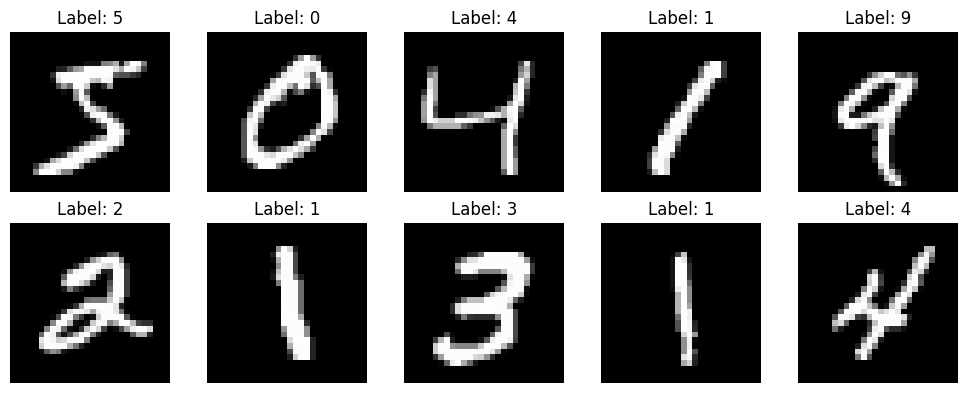

In [5]:
plt.figure(figsize=(10, 4))

for i in range(10):
  plt.subplot(2, 5, i + 1)
  plt.imshow(x_train[i], cmap="gray")
  plt.title(f"Label: {y_train[i]}")
  plt.axis("off")

plt.tight_layout()
plt.show()

2. Build a Fully Connected Neural Network

Define a sequential model using Keras
Flatten the 28x28 input images into a single vector
Add two hidden layers with ReLU activation
Add an output layer with Softmax activation for multi-class classification
Compile the model using categorical cross-entropy as the loss function and accuracy as the evaluation metric

In [6]:
model = Sequential([
  Flatten(input_shape=(28, 28)),

  Dense(128, activation="relu"),
  Dense(64, activation="relu"),

  Dense(10, activation="softmax")
])

model.compile(
  optimizer="adam",
  loss="categorical_crossentropy",
  metrics=["accuracy"]
)

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

3. Train the Neural Network

Fit the model to the training data for 10 epochs
Use a validation set to track performance during training

In [7]:
history = model.fit(
  x_train,
  y_train_oh,
  epochs=10,
  batch_size=128,
  validation_split=0.1
)

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8972 - loss: 0.3644 - val_accuracy: 0.9605 - val_loss: 0.1453
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9579 - loss: 0.1435 - val_accuracy: 0.9698 - val_loss: 0.1071
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9715 - loss: 0.0974 - val_accuracy: 0.9747 - val_loss: 0.0921
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9780 - loss: 0.0730 - val_accuracy: 0.9728 - val_loss: 0.0928
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9830 - loss: 0.0568 - val_accuracy: 0.9773 - val_loss: 0.0797
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9856 - loss: 0.0474 - val_accuracy: 0.9770 - val_loss: 0.0860
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9883 - loss: 0.0379 - val_accuracy: 0.9742 - val_loss: 0.0932
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9901 - loss: 0.0321 - val_accuracy: 0.

Observe the loss over the epochs

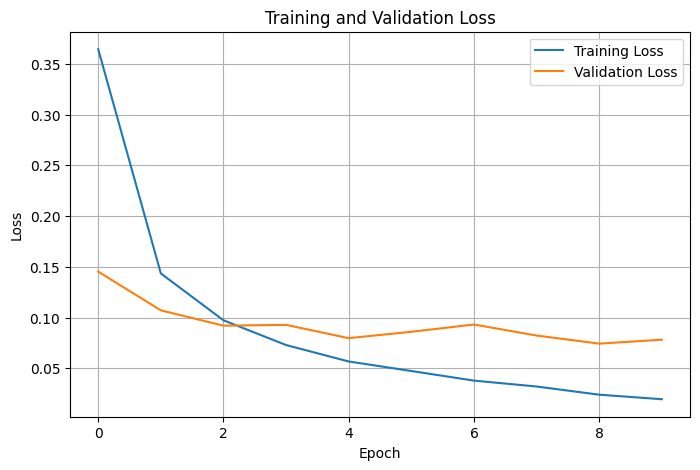

In [8]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

observe accuracy trends over the epochs

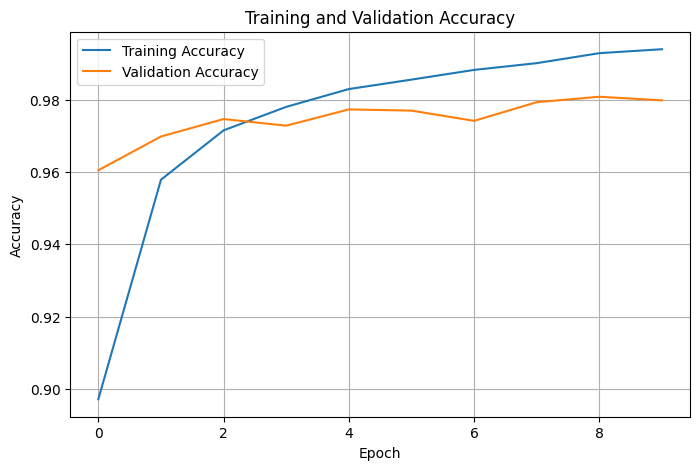

In [10]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()


4. Evaluate the Model’s Performance

Compute accuracy on the test dataset


In [11]:
test_loss, test_accuracy = model.evaluate(
x_test,
y_test_oh,
verbose=0
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Test Loss: 0.0700
Test Accuracy: 0.9802


Display a confusion matrix for misclassified digits
Identify which digits the model struggles with the most

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


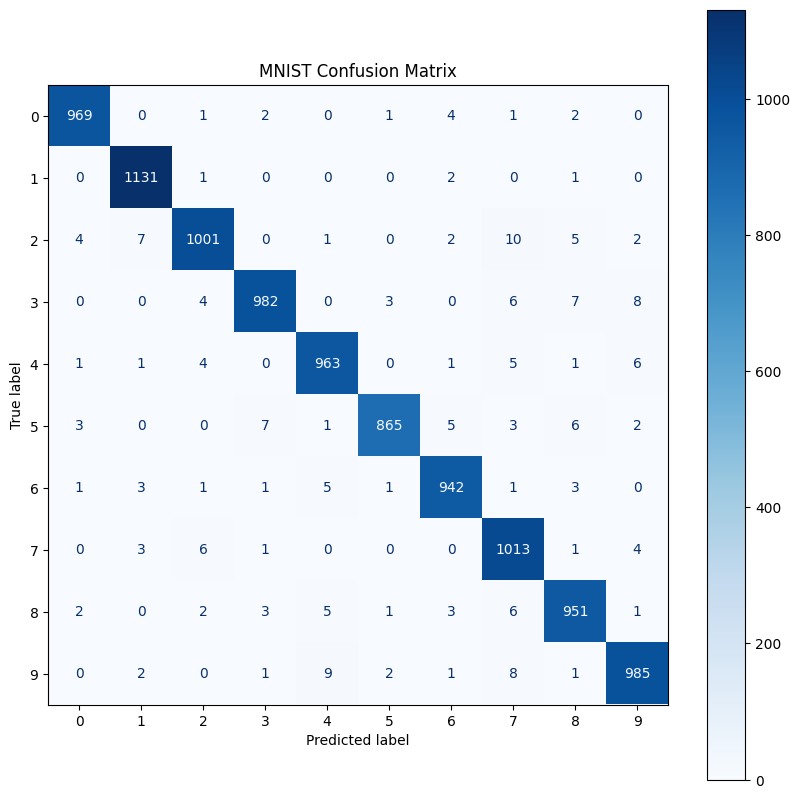

In [12]:
y_prob = model.predict(x_test)
y_pred = np.argmax(y_prob, axis=1)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
  confusion_matrix=cm,
  display_labels=range(10)
)

fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(ax=ax, cmap="Blues", values_format="d")

plt.title("MNIST Confusion Matrix")
plt.show()

Identify which digits the model struggles with the most

In [13]:
errors_by_digit = {}

for digit in range(10):
  mask = y_test == digit

  total = np.sum(mask)
  correct = np.sum(y_pred[mask] == digit)
  errors = total - correct

  errors_by_digit[digit] = errors

for digit, errors in errors_by_digit.items():
    print(f"Digit {digit}: {errors} misclassified")

Digit 0: 11 misclassified
Digit 1: 4 misclassified
Digit 2: 31 misclassified
Digit 3: 28 misclassified
Digit 4: 19 misclassified
Digit 5: 27 misclassified
Digit 6: 16 misclassified
Digit 7: 15 misclassified
Digit 8: 23 misclassified
Digit 9: 24 misclassified


In [14]:
worst_digit = max(errors_by_digit, key=errors_by_digit.get)

print(
  "Digit with the most misclassifications:",
  worst_digit
)

Digit with the most misclassifications: 2


Conclusion:
The fully connected neural network achieved a test accuracy of 98.02% with a test loss of 0.0700. The confusion matrix shows that the model performs well across all ten MNIST digit classes. Digit 2 had the highest number of misclassifications, with 31 errors, followed by digit 3 with 28 errors and digit 5 with 27 errors. Overall, the model demonstrates strong performance on the MNIST handwritten digit classification task.